In [1]:
from customhys import benchmark_func as bf

import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

import numpy as np
import pandas as pd

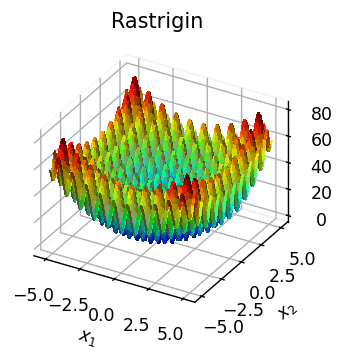

In [2]:
num_dimensions = 2
fun = bf.Rastrigin(num_dimensions)
fun.plot(samples=100, resolution=125)
plt.show()

## 3. Module of Operators (customhys.operators)
In this section we will see one of the most important modules, this is the one of the operators that will help us to build the desired algorithm.

In [3]:
from customhys import operators as op

Let us see the available operators:

In [4]:
print('Perturbadores: ', op.__all__)

Perturbadores:  ['local_random_walk', 'random_search', 'random_sample', 'random_flight', 'differential_mutation', 'firefly_dynamic', 'swarm_dynamic', 'gravitational_search', 'central_force_dynamic', 'spiral_dynamic', 'genetic_mutation', 'genetic_crossover', 'linear_system']


In [5]:
print('Selectores: ', op.__selectors__)

Selectores:  ['all', 'greedy', 'metropolis', 'probabilistic']


In [6]:
op_task = op.obtain_operators(num_vals=5)
print(op_task.__len__(), op_task)

16 [('random_search', {'scale': [1.0], 'distribution': ['uniform']}, ['greedy']), ('central_force_dynamic', {'gravity': [0.0, 0.0025, 0.005, 0.0075, 0.01], 'alpha': [0.0, 0.0025, 0.005, 0.0075, 0.01], 'beta': [1.0, 1.25, 1.5, 1.75, 2.0], 'dt': [0.0, 0.5, 1.0, 1.5, 2.0]}, ['all', 'greedy', 'metropolis', 'probabilistic']), ('differential_crossover', {'crossover_rate': [0.0, 0.25, 0.5, 0.75, 1.0], 'version': ['binomial', 'exponential']}, ['all', 'greedy', 'metropolis', 'probabilistic']), ('differential_mutation', {'expression': ['rand', 'best', 'current', 'current-to-best', 'rand-to-best', 'rand-to-best-and-current'], 'num_rands': [1, 2, 3], 'factor': [0.0, 0.625, 1.25, 1.875, 2.5]}, ['all', 'greedy', 'metropolis', 'probabilistic']), ('firefly_dynamic', {'distribution': ['uniform', 'gaussian', 'levy'], 'alpha': [0.0, 0.125, 0.25, 0.375, 0.5], 'beta': [0.01, 0.2575, 0.505, 0.7525, 1.0], 'gamma': [1.0, 250.75, 500.5, 750.25, 1000.0]}, ['all', 'greedy', 'metropolis', 'probabilistic']), ('gen

In [7]:
from customhys import  population as pp

num_agents = 20
pop = pp.Population(fun.get_search_range(), num_agents=num_agents)
pop.initialise_positions('random')

num_dimensions = 2

In [8]:
# get the matrices
matrices, mask = op.generate_mixed_matrices(
    dim=num_dimensions,
    n=num_agents,
    stable_ratio=0.95,
)
matrices

array([[[-3.57554750e-01,  1.68047806e-01],
        [-1.68047806e-01, -3.57554750e-01]],

       [[ 5.88047635e-02, -7.79163250e-01],
        [-7.79163250e-01, -1.69768093e-01]],

       [[-7.79357825e-01,  2.45642217e-01],
        [-2.45642217e-01, -7.79357825e-01]],

       [[-5.03631597e-01,  1.23663565e-01],
        [-1.23663565e-01, -5.03631597e-01]],

       [[-3.77522751e-01,  5.43006023e-01],
        [-5.43006023e-01, -3.77522751e-01]],

       [[-3.37202038e-01,  9.03999383e-02],
        [-9.03999383e-02, -3.37202038e-01]],

       [[ 7.28332169e-01, -4.90238567e-02],
        [-4.90238567e-02,  3.12899156e-01]],

       [[ 2.33040019e-01,  5.42043201e-01],
        [-5.42043201e-01,  2.33040019e-01]],

       [[-1.17234024e+00,  5.36422999e-03],
        [ 5.36422999e-03, -4.02390064e-01]],

       [[ 7.36016839e-01, -1.33789994e-01],
        [-1.33789994e-01,  7.07276054e-01]],

       [[ 1.94666920e-01, -5.40804087e-01],
        [-5.40804087e-01, -6.22353955e-01]],

       [[ 

In [9]:
fun = bf.CrossLegTable(num_dimensions)

# Initial population
pop.initialise_positions('random')

# Evaluate the initial positions
pop.evaluate_fitness(lambda x: fun.get_function_value(x))

# Update the positions and fitness
pop.update_positions(level='population', selector='all')
pop.update_positions(level='global', selector='greedy')

# Save the initial state
history = [pop.fitness.copy()]
positions = [pop.positions.copy()]
gbests = [pop.global_best_position.copy()]

max_iterations = 1000

iterations = np.arange(max_iterations)

print(fun.optimal_fitness)

for iteration in iterations:
    # Apply the perturbation heuristic
    # exec(op_to_exect)
    # op.central_force_dynamic(pop, alpha=0.9, beta=0.45)
    op.linear_system(pop, matrices,
                     dt=0.1,
                     offset="particularbest", # subpopmean | globalbest
                     noise=0.01
                     ) # subpopmean | globalbest

    # Evaluate the new positions
    pop.evaluate_fitness(lambda x: fun.get_function_value(x))

    # Choose random selectors (alpha version)
    # selector = list(np.random.choice(
    #     ['direct', 'greedy', 'probabilistic'],
    #     pop.num_agents))
    selector = 'greedy'

    # Update the positions
    pop.update_positions(level='population', selector=selector)
    pop.update_positions(level='global')   
    
    # Save the fitness
    history.append(pop.fitness.copy())

    # Show positions
    positions.append(np.array(pop.get_positions()))
    gbests.append(pop.global_best_position.copy())

    if iteration % (max_iterations/10) == 0:
        print(f"{iteration}: {pop.global_best_fitness}")


0
0: -0.00015158957640263145
100: -0.00015158957640263145
200: -0.00015742001179432257
300: -0.00015742001179432257
400: -0.00015742001179432257
500: -0.00015742001179432257
600: -0.00015742001179432257
700: -0.00015742001179432257
800: -0.00015742001179432257
900: -0.00015742001179432257


In [10]:
pos_vec = np.asarray(positions)
gbest_vec = np.asarray(gbests)
pos_vec.shape

(1001, 20, 2)

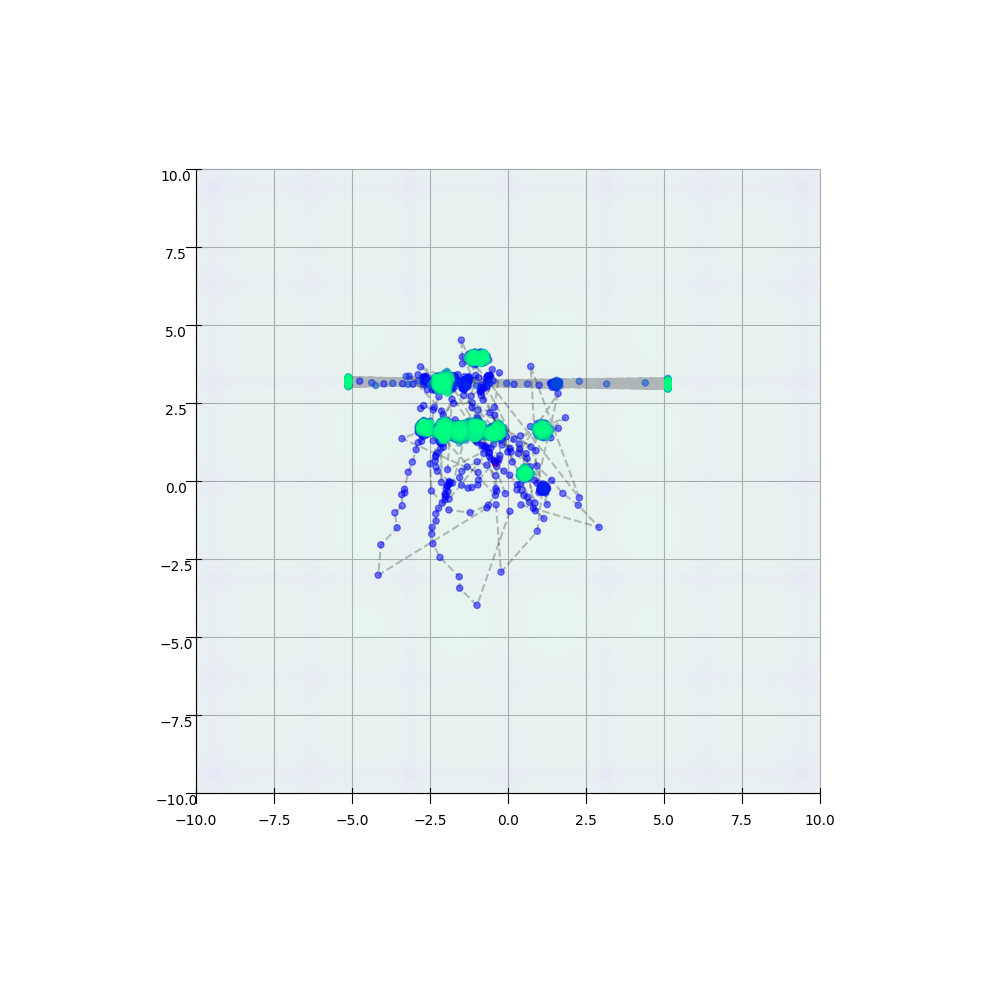

In [11]:
# Colormap for iterations and a matching normalisation + colorbar
norm = mpl.colors.Normalize(vmin=0, vmax=max_iterations)
scalar_cmap = plt.get_cmap("winter", max_iterations + 1)
colors = scalar_cmap(np.linspace(0, 1, max_iterations + 1))
sm = plt.cm.ScalarMappable(cmap=scalar_cmap, norm=norm)
sm.set_array([])

# Camera/view + surface backdrop
azim, elev = -90, 90
samples = 100
space_constraints = np.array(fun.get_search_range()).T  # shape (2,2) for 2D
X, Y = np.meshgrid(
    np.linspace(*space_constraints[0], samples),
    np.linspace(*space_constraints[1], samples)
)
Z = np.array([fun.get_function_value([x, y]) for x, y in zip(X.ravel(), Y.ravel())]).reshape(X.shape)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d', proj_type='ortho')
ax.plot_surface(X, Y, Z, rstride=1, cstride=1, linewidth=0.5,
                antialiased=True, cmap=plt.cm.winter, alpha=0.05)
ax.set_zticks([])
ax.zaxis.set_visible(False)

for agent in range(num_agents):
    ax.plot(
        pos_vec[:, agent, 0],
        pos_vec[:, agent, 1],
        "k--", alpha=0.25
    )

# Scatter each iteration at z = iteration, colored by the iteration index
for iteration in range(max_iterations + 1):
    ax.scatter(
        pos_vec[iteration, :, 0],
        pos_vec[iteration, :, 1],
        np.full(pos_vec.shape[1], iteration),  # z = iteration for this layer
        c=np.full(pos_vec.shape[1], iteration),
        cmap=scalar_cmap, norm=norm,
        s=20, alpha=0.5, #edgecolors='none'
    )

    # global best marker at this iteration (plotted at same z)
ax.plot(
    gbest_vec[:, 0],
    gbest_vec[:, 1],
    np.arange(1, gbest_vec.shape[0] + 1),
    'r--*', linewidth=1.5,
)

ax.view_init(elev, azim)
ax.set_xlim([*space_constraints[0]])
ax.set_ylim([*space_constraints[1]])
plt.tight_layout()
plt.show()

Let us plot the historical values of the fitness

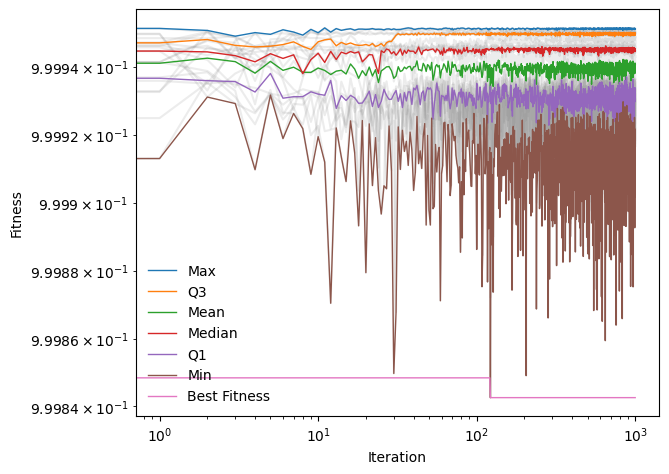

In [12]:
# Process the historical values
history = np.array(history) + 1

# Determine the best
best_fitness_per_step = history.min(axis=1)

# best_fitness is the best fitness so far at i step
best_fitness = np.array([np.min(best_fitness_per_step[:step]) for step in range(1, max_iterations + 1)])

plt.figure()
# plot in gray scale to after plot some statistics above
plt.plot(history, color='gray', alpha=0.15)
plt.plot(history.max(axis=1), lw=1, label='Max')
plt.plot(np.quantile(history, 0.75, axis=1), lw=1, label='Q3')
plt.plot(history.mean(axis=1), lw=1, label='Mean')
plt.plot(np.median(history, axis=1), lw=1, label='Median')
plt.plot(np.quantile(history, 0.25, axis=1), lw=1, label='Q1')
plt.plot(history.min(axis=1), lw=1, label='Min')
#plt.plot(history.std(axis=1), lw=2, label='Std')

plt.plot(best_fitness, lw=1, label='Best Fitness')

plt.legend(frameon=False)
plt.xlabel('Iteration'), plt.ylabel('Fitness')
plt.tight_layout()
plt.xscale('log')
plt.yscale('log')
plt.show()

        ## 4. Module of Metaheuristics (customhys.metaheuristic)
In this section, we will see how to use the module to build a metaheuristics.

In [13]:
from customhys import metaheuristic as mh
fun = bf.Rastrigin(3)
prob = fun.get_formatted_problem()

prob

{'function': <function customhys.benchmark_func.BasicProblem.get_formatted_problem.<locals>.<lambda>(x)>,
 'boundaries': (array([-5.12, -5.12, -5.12]), array([5.12, 5.12, 5.12])),
 'is_constrained': True,
 'features': '110',
 'func_name': 'Rastrigin',
 'dimensions': 3}

In [14]:
matrices[0].shape

(2, 2)

In [17]:
heur = [( # Search operator 1
    'linear_system',  # Perturbator
    {  # Parameters
        'matrix': matrices[0],
        'dt': 0.01,
        'offset': 'globalbest', # subpopmean
    },
    'greedy'  # Selector
)]


met = mh.Metaheuristic(prob, heur, num_iterations=1000)
met.verbose = True
met.run()
print('x_best = {}, f_best = {}'.format(*met.get_solution()))


Search operators to employ:
linear_system(matrix=[[-0.35755475  0.16804781]
 [-0.16804781 -0.35755475]],dt=0.01,offset='globalbest') with greedy
--------------------------------------------------


OperatorsError: matrix must have shape (num_dimensions,num_dimensions) or (num_agents,num_dimensions,num_dimensions)

In [ ]:
met.historical["fitness"]

In [ ]:
hist_values = met.historical

plt.figure()
plt.plot(hist_values)
plt.plot(hist_values['fitness'], lw=2)
plt.xlabel('Iteration'), plt.ylabel('Fitness')
plt.tight_layout()
plt.show()
# plt.savefig('ExFitness.svg')

In [ ]:
plt.figure()
plt.plot(hist_values['centroid'])
plt.xlabel(r'Iteration'), plt.ylabel(r'Centroid')
plt.legend([r'$x_1$', r'$x_2$', r'$x_3$'], frameon=False)
plt.tight_layout()
plt.show()
# plt.savefig('ExCentroid.svg')

In [ ]:
plt.figure()
plt.plot(hist_values['radius'])
plt.xlabel(r'Iteration'), plt.ylabel(r'Radius')
plt.tight_layout()
plt.show()
# plt.savefig('E|xRadius.svg')

Let us try another metaheuristic

In [ ]:
# This the minimisation problem to solve
fun = bf.Griewank(6)
prob = fun.get_formatted_problem()
fun.plot()

In [ ]:
# This will be the metaheuristic
heu_seq = [
    ('random_search', {'scale': 1.0, 'distribution': 'uniform'}, 'greedy'),
    ('spiral_dynamic', {'radius': 0.9, 'angle': 33.5, 'sigma': 0.1}, 'all'),
    ('gravitational_search', {'gravity': 0.5, 'alpha': 0.2}, 'metropolis')
    ]
met = mh.Metaheuristic(prob, heu_seq, num_iterations=5000, num_agents=100)
met.verbose = False
met.run()
print('x_best = {}, f_best = {}'.format(*met.get_solution()))

In [ ]:
hist_values = met.historical

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(hist_values['fitness'], lw=2)
axs[0].set_xlabel('Iteration'), axs[0].set_ylabel('Fitness')

axs[1].plot(hist_values['position'])
axs[1].set_xlabel(r'Iteration'), axs[1].set_ylabel(r'Position')
axs[1].legend([f"$x_{ii+1}$" for ii in range(6)], frameon=False)

plt.show()

In [ ]:
# Initialise the fitness register
fitness = []
# Run the metaheuristic with the same problem 30 times
for rep in range(30):
    met = mh.Metaheuristic(prob, heu_seq, num_iterations=1000, num_agents=100)
    met.reset_historicals()
    met.verbose = False
    met.run()
    print('rep = {}, x_best = {}, f_best = {}'.format(rep+1, *met.get_solution()))
    
    fitness.append(met.historical['fitness'])

In [ ]:
fitness

In [ ]:
fitness_array = np.array(fitness).T
final_fitness = np.array([x[-1] for x in fitness_array.T])
best_fitness = np.min(fitness_array)
initial_fitness = max([x[0] for x in fitness_array])

# Now plot the fitness values
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), sharey='row', gridspec_kw={'width_ratios': [0.8, 0.2]})
axs[0].plot(fitness_array, 'grey', alpha=0.3)

axs[0].plot(np.min(fitness_array, axis=1), 'g', lw=2, label='Best')
axs[0].plot(np.max(fitness_array, axis=1), 'k', lw=2, label='Worst')
axs[0].plot(np.mean(fitness_array, axis=1), 'b', lw=2, label='Mean')
axs[0].plot(np.median(fitness_array, axis=1), 'r', lw=2, label='Median')

axs[0].set_ylabel(r'Fitness')
axs[0].set_xlabel(r'Iteration')
axs[0].set_ylim([best_fitness, initial_fitness])

# Violin plot
axs[1].violinplot(final_fitness, showmeans=True, showmedians=True)
axs[1].set_xlabel(r'Data')

axs[0].legend(frameon=False)

axs[0].set_yscale('log')
axs[1].set_yscale('log')
axs[0].set_xscale('log')
plt.tight_layout()
plt.show()

## 5. Module of Hyper-Heuristics (customhys.hyperheuristic)
This section is dedicated to the use of the module to implement a hyper-heuristic for finding the most suitable metaheuristic for a given problem.

In [ ]:
parameters = dict(
    cardinality=3,  # Max. numb. of SOs in MHs, lvl:1
    cardinality_min=1,  # Min. numb. of SOs in MHs, lvl:1
    num_iterations=100,  # Iterations an MH performs, lvl:1
    num_agents=30,  # Agents in population,     lvl:1
    as_mh=True,  # HH sequence as a MH?,     lvl:2
    num_replicas=30,  # Replicas per each MH,     lvl:2
    num_steps=50,  # Trials per HH step,       lvl:2
    stagnation_percentage=0.37,  # Stagnation percentage,    lvl:2
    max_temperature=100,  # Initial temperature (SA), lvl:2
    min_temperature=1e-6,  # Min temperature (SA),     lvl:2
    cooling_rate=1e-3,  # Cooling rate (SA),        lvl:2
    temperature_scheme='fast',  # Temperature updating (SA),lvl:2
    acceptance_scheme='exponential',  # Acceptance mode,          lvl:2
    allow_weight_matrix=True,  # Weight matrix,            lvl:2
    trial_overflow=False,  # Trial overflow policy,    lvl:2
    learnt_dataset=None,  # If it is a learnt dataset related with the heuristic space
    repeat_operators=True,  # Allow repeating SOs inSeq,lvl:2
    verbose=True,  # Verbose process,          lvl:2
    learning_portion=0.37,  # Percent of seqs to learn  lvl:2
    solver='static')  # Indicate which solver use lvl:1

In [ ]:
from customhys import hyperheuristic as hh

dime = 5
fun = bf.Griewank(dime)

cate = fun.get_features()
prob = fun.get_formatted_problem()

hyp = hh.Hyperheuristic(heuristic_space="default.txt",
                        problem=prob, parameters=parameters, file_label='Griewank-5D-Exp2')

best_sol, best_perf, hist_curr, hist_best = hyp.solve()

In [ ]:
# print("Performance: ", best_perf)
# print(best_sol)

In [ ]:
from customhys import tools as tl
full_data = tl.merge_json("./data_files/raw/Griewank-5D-Exp2")
# full_data = tl.read_json("./Exp1.json")

In [ ]:
full_data = tl.read_json("./data_files/raw/Griewank-5D-Exp2.json")

In [ ]:
tl.printmsk(full_data)

In [ ]:
num_steps = len(full_data)
# print(full_data['details'])
# historical_fitness = [[x[['fitness']][-1] for x in historical] for historical in full_data['details']]
historical_fitness = [x['details']['fitness'] for x in full_data]
performances = [x['performance'] for x in full_data]
steps = [x['step'] for x in full_data]


In [ ]:
from customhys import visualisation as vis
vis.show_performance_overview(steps, historical_fitness, performances)

In [ ]:
initial_fitness = max([max([x['fitness'][0] for x in fitness_rep['details']['historical']]) for fitness_rep in full_data])
best_fitness = np.min(historical_fitness)

for ii, step in enumerate(steps):
    historical_data = full_data[ii]['details']['historical']
    all_fitness_repetitions = np.array([fitness_rep['fitness'] for fitness_rep in historical_data]).T

    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), sharey='row', gridspec_kw={'width_ratios': [0.8, 0.2]})
    axs[0].plot(all_fitness_repetitions, 'g', alpha=0.75)
    axs[0].set_ylabel(r'Fitness')
    axs[0].set_xlabel(r'Iteration')
    axs[0].set_ylim([best_fitness, initial_fitness])

    axs[1].boxplot(historical_fitness[ii])
    axs[1].set_xlabel(r'Data')

    plt.suptitle(r'MH$^{' + '{}'.format(len(full_data[ii]['encoded_solution'])) + '} = \\{' +
              '}, '.join(['h_{' + str(x) for x in full_data[ii]['encoded_solution']]) + '}\\}$')
    plt.tight_layout()
    plt.show()
    # plt.savefig('hh_raw_fitness_s{}.eps'.format(data['step'][ii]))


In [ ]:
met = mh.Metaheuristic(prob, heu_seq, num_iterations=1000)
met.verbose = True
met.run()
print('x_best = {}, f_best = {}'.format(*met.get_solution()))

In [ ]:
hist_values = met.historical
tl.printmsk(hist_values)

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(hist_values['fitness'], lw=2)
axs[0].set_xlabel('Iteration'), axs[0].set_ylabel('Fitness')

axs[1].plot(hist_values['position'])
# axs[1].plot(hist_values['radius'])
axs[1].set_xlabel(r'Iteration'), axs[1].set_ylabel(r'Position')
axs[1].legend([f"$x_{ii+1}$" for ii in range(6)], frameon=False)

plt.show()

### 5.1 Using CEC2005 functions
To use them we need to install the package `optproblems`

In [ ]:
#!pip install optproblems

In [ ]:
from customhys import benchmark_func as bf

In [ ]:
problem = bf.CEC2005("F4", 5)

In [ ]:
met = mh.Metaheuristic(problem.get_formatted_problem(), heur, num_iterations=1000)
met.verbose = True
met.run()
print('x_best = {}, f_best = {}'.format(*met.get_solution()))

In [ ]:
hist_values = met.historical
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(hist_values['fitness'], lw=2)
axs[0].set_xlabel('Iteration'), axs[0].set_ylabel('Fitness')

axs[1].plot(hist_values['position'])
# axs[1].plot(hist_values['radius'])
axs[1].set_xlabel(r'Iteration'), axs[1].set_ylabel(r'Position')
axs[1].legend([f"$x_{ii+1}$" for ii in range(6)], frameon=False)

plt.show()

In [ ]:
dime = 20
fun = bf.CEC2005("F4", dime)

cate = fun.get_features()
prob = fun.get_formatted_problem()

hyp = hh.Hyperheuristic(heuristic_space="default.txt",
                        problem=prob, parameters=parameters, file_label='CEC-F4-20D-Exp2')

best_sol, best_perf, hist_curr, hist_best = hyp.solve()

In [ ]:
full_data = tl.merge_json("./data_files/raw/CEC-F4-20D-Exp2")

In [ ]:
full_data = tl.read_json("./data_files/raw/CEC-F4-20D-Exp2.json")

In [ ]:
num_steps = len(full_data)
# print(full_data['details'])
# historical_fitness = [[x[['fitness']][-1] for x in historical] for historical in full_data['details']]
historical_fitness = [x['details']['fitness'] for x in full_data]
performances = [x['performance'] for x in full_data]
steps = [x['step'] for x in full_data]

vis.show_performance_overview(steps, historical_fitness, performances)

In [ ]:
initial_fitness = max([max([x['fitness'][0] for x in fitness_rep['details']['historical']]) for fitness_rep in full_data])
best_fitness = np.min(historical_fitness)

for ii, step in enumerate(steps):
    historical_data = full_data[ii]['details']['historical']
    all_fitness_repetitions = np.array([fitness_rep['fitness'] for fitness_rep in historical_data]).T

    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), sharey='row', gridspec_kw={'width_ratios': [0.8, 0.2]})
    axs[0].plot(all_fitness_repetitions, 'g', alpha=0.75)
    axs[0].set_ylabel(r'Fitness')
    axs[0].set_xlabel(r'Iteration')
    axs[0].set_ylim([best_fitness, initial_fitness])

    axs[1].boxplot(historical_fitness[ii])
    axs[1].set_xlabel(r'Data')

    plt.suptitle(r'MH$^{' + '{}'.format(len(full_data[ii]['encoded_solution'])) + '} = \\{' +
              '}, '.join(['h_{' + str(x) for x in full_data[ii]['encoded_solution']]) + '}\\}$')
    plt.tight_layout()
    plt.show()
    # plt.savefig('hh_raw_fitness_s{}.eps'.format(data['step'][ii]))
